# Set up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset

In [2]:
df = pd.read_csv('SpaceshipTitanic.csv')
print(df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


# Check datatype and non-null counts

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


# Count nulls

In [4]:
nullCount = df.isnull().sum()
print(f"missing values count:\n{nullCount}")

missing values count:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


# Clean Data

In [5]:
spendings_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df[spendings_cols] = df[spendings_cols].fillna(0)

df['Age'] = df['Age'].fillna(df['Age'].median())

cat_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Cabin'] = df['Cabin'].fillna('Unknown/Unknown/Unknown')
df['Name'] = df['Name'].fillna('Unknown Unknown')

# Generate Summary Statistics

In [6]:
print(df.describe())

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8693.000000   8693.000000   8693.000000   8693.000000   8693.000000   
mean     28.790291    220.009318    448.434027    169.572300    304.588865   
std      14.341404    660.519050   1595.790627    598.007164   1125.562559   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      20.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      37.000000     41.000000     61.000000     22.000000     53.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8693.000000  
mean     298.261820  
std     1134.126417  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       40.000000  
max    24133.000000  


# Feature Extraction

In [7]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# clean CryoSleep
df['CryoSleep_Inferred'] = np.where(df['TotalSpending'] > 0, False, True)
df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep_Inferred'])
df.drop(columns=['CryoSleep_Inferred'], inplace=True)

df['CabinDeck'] = df['Cabin'].str.split('/', expand=True)[0]
df['CabinSide'] = df['Cabin'].str.split('/', expand=True)[2]

print(df[['TotalSpending', 'CabinDeck', 'CabinSide']].head())

   TotalSpending CabinDeck CabinSide
0            0.0         B         P
1          736.0         F         S
2        10383.0         A         S
3         5176.0         A         S
4         1091.0         F         S


# Correlation with Transfer

## Age

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


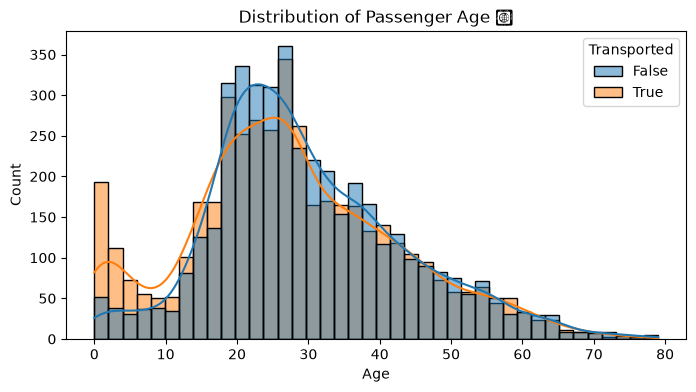

In [8]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='Age', kde=True, bins=40, hue="Transported")
plt.title('Distribution of Passenger Age 👤')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Insights:
- majority of passengers are young adults
- notable amount of passengers are babies and infants
- most babies/infants have high survival rates compared to other age group
- most young adults have low survial rates compared to other age group

## Cryo sleep

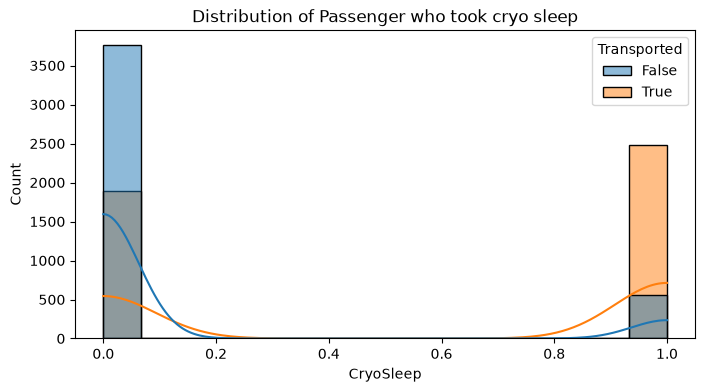

In [9]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='CryoSleep', kde=True, hue="Transported")
plt.title('Distribution of Passenger who took cryo sleep')
plt.xlabel('CryoSleep')
plt.ylabel('Count')
plt.show()

Insights:
- Passengers who take cryo sleep are more likely to be transported

## Cabin Deck

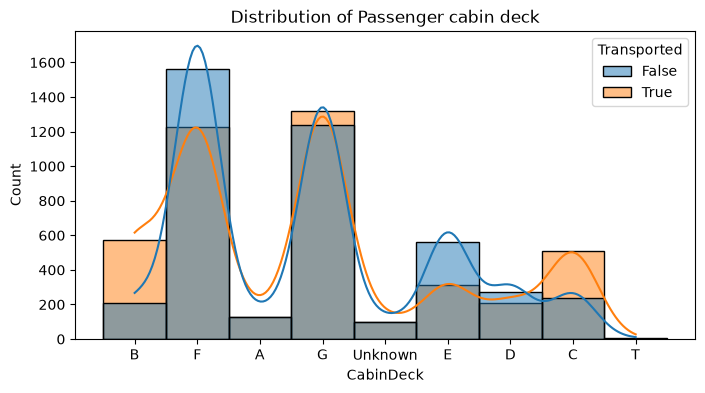

In [10]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='CabinDeck', kde=True, hue="Transported")
plt.title('Distribution of Passenger cabin deck')
plt.xlabel('CabinDeck')
plt.ylabel('Count')
plt.show()

Insights:
- Most passengers took cabin deck F and G
- Passenger who took cabin deck B and C are more likely to be transported

## CabinSide

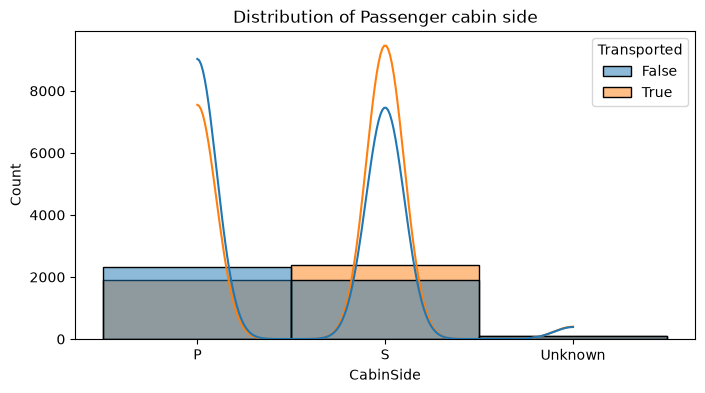

In [11]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='CabinSide', kde=True, hue="Transported")
plt.title('Distribution of Passenger cabin side')
plt.xlabel('CabinSide')
plt.ylabel('Count')
plt.show()

Insights:
- The amount of passenger who took cabin side P and S are roughly the same
- Passengers who took cabin side S have a slightly more chance of being transported than cabin side P

## TotalSpendings

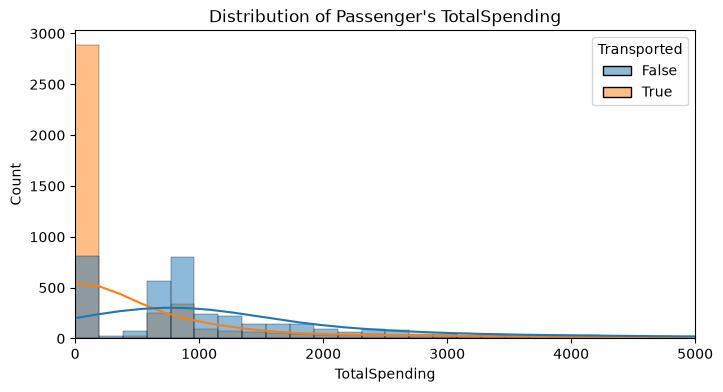

In [12]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='TotalSpending', kde=True, hue="Transported")
plt.xlim(0, 5000)
plt.title('Distribution of Passenger\'s TotalSpending')
plt.xlabel('TotalSpending')
plt.ylabel('Count')
plt.show()

Insights:
- All passengers spends $0 are the one tho took cryo sleep
- Most passengers spends around $800 - $900
- Passengers who spent money (didn't take cryo sleep) are likely to not be transported

## VIP

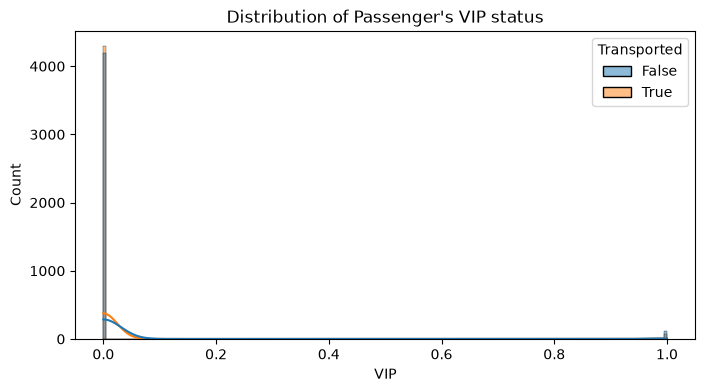

In [13]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='VIP', kde=True, hue="Transported")
plt.title('Distribution of Passenger\'s VIP status')
plt.xlabel('VIP')
plt.ylabel('Count')
plt.show()

Insights:
- Most passengers are not VIP
- If a passenger is a VIP, they are likely to not be transported

## Destination

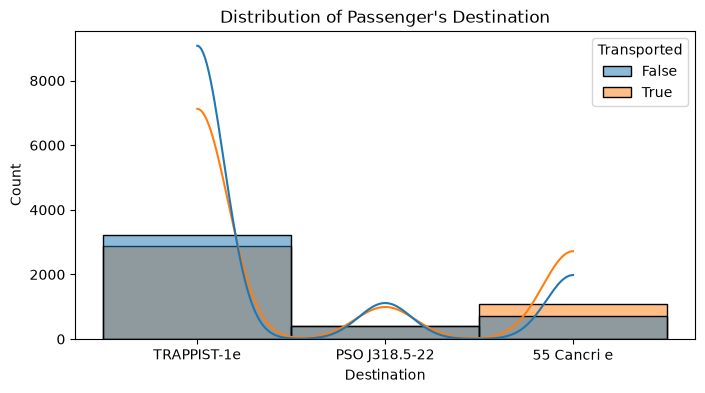

In [14]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='Destination', kde=True, hue="Transported")
plt.title('Distribution of Passenger\'s Destination')
plt.xlabel('Destination')
plt.ylabel('Count')
plt.show()

Insights:
- Most passenger's destination is TRAPPIST-1e
- passengers who are visiting 55 Cancrie are likely to be transported
- passengers who are visiting 5TRAPPIST-1e are likely to not be transported

## Home Planet

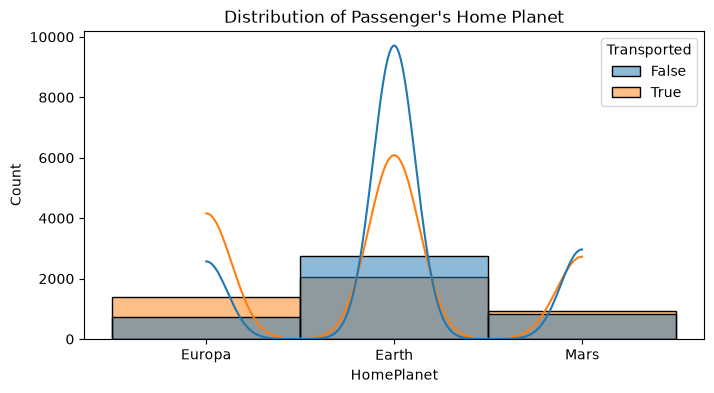

In [15]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='HomePlanet', kde=True, hue="Transported")
plt.title('Distribution of Passenger\'s Home Planet')
plt.xlabel('HomePlanet')
plt.ylabel('Count')
plt.show()

Insights:
- Most passenger's are from Earth
- passengers who are from Europa are likely to be transported
- passengers who are from Earth are likely to not be transported

# Other correlation

## Home Planet X Age

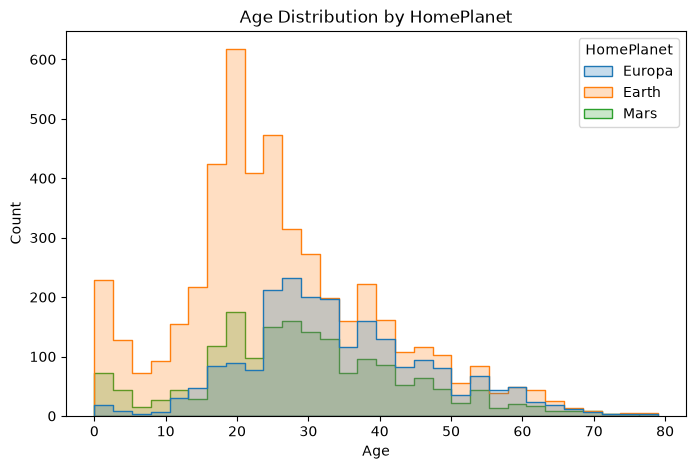

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="HomePlanet", bins=30, element="step", common_norm=False)

plt.title("Age Distribution by HomePlanet")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insights:
- Most passengers are around 20 years old
- Most passengers are from Earth
- Most Earth passengers are around 20 years old
- Most Europa passengers are around 25 - 35 years old
- Most Mars passengers are also around 20 years old

## Destination X CryoSleep

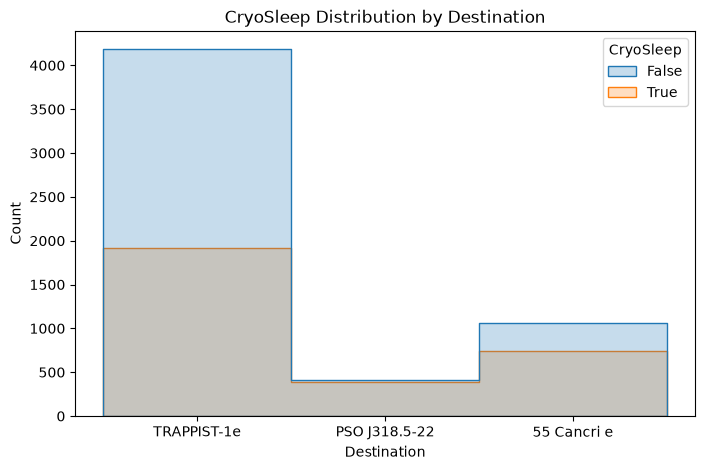

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Destination", hue="CryoSleep", bins=30, element="step", common_norm=False)

plt.title("CryoSleep Distribution by Destination")
plt.xlabel("Destination")
plt.ylabel("Count")
plt.show()

Insights:
- Majority of the passengers did not take CryoSleep
- Over half of the passengers who are going to TRAPPIST-1e did not take CryoSleep

## Age X CryoSleep

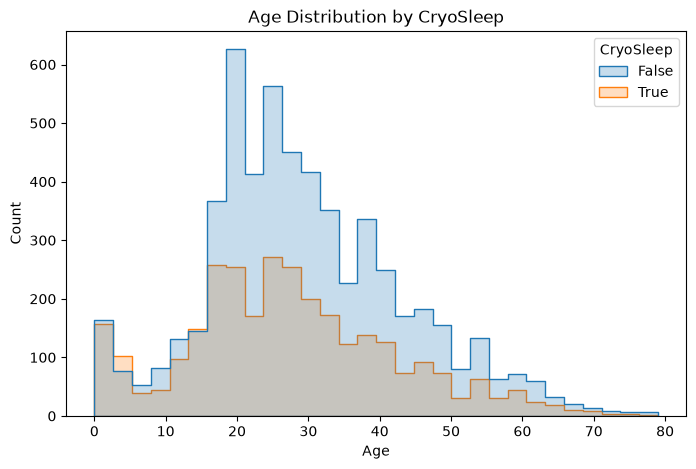

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="CryoSleep", bins=30, element="step", common_norm=False)

plt.title("Age Distribution by CryoSleep")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insights:
- Most of passengers who are 2.5 - 5 years old took CryoSleep
- The majority of passengers who did not take CryoSleep are around 20 years old
- The majority of passengers who took CryoSleep are around 25 years old 